## Exercise:

1. Load dataset into pandas DataFrame  
2. Remove outliers using Z-score (keep values between -3 and 3)  
3. Encode categorical columns (Label Encoding / One-Hot Encoding)  
4. Apply feature scaling  
5. Train SVM (standalone + bagging) and compare performance  
6. Train Decision Tree (standalone + bagging) and compare performance  
7. Compare SVM vs Decision Tree and analyze where bagging works best  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv("/content/heart (1).csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
numeric_col=['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
categorical_col=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [7]:
df.shape

(918, 12)

In [10]:
for i in numeric_col:
  mean= df[i].mean()
  std= df[i].std()
  z_score= (df[i]-mean)/std
  df = df[(z_score < 3) & (z_score > -3)]

In [11]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [12]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,899.000000,899.000000,899.000000,899.000000,899.000000,899.000000,899.000000
mean,53.497219,132.027809,198.005562,0.232481,136.917686,0.861513,0.547275
std,9.456073,17.120895,107.157779,0.422649,25.356740,1.007626,0.498037
min,28.000000,80.000000,0.000000,0.000000,63.000000,-2.000000,0.000000
25%,47.000000,120.000000,174.500000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,222.000000,0.000000,138.000000,0.500000,1.000000
75%,60.000000,140.000000,266.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,185.000000,518.000000,1.000000,202.000000,4.000000,1.000000


In [13]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
for i in categorical_col:
  df[i]= le.fit_transform(df[i])

In [14]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [15]:
df.shape

(899, 12)

In [16]:
target= df['HeartDisease']

In [17]:
df=df.drop('HeartDisease', axis=1)

In [18]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,1,1,140,289,0,1,172,0,0.0,2
1,49,0,2,160,180,0,1,156,0,1.0,1
2,37,1,1,130,283,0,2,98,0,0.0,2
3,48,0,0,138,214,0,1,108,1,1.5,1
4,54,1,2,150,195,0,1,122,0,0.0,2


In [19]:
X= df

In [20]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_scaled= sc.fit_transform(X)

## SVM (Standalone and Bagging)

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X_scaled, target, test_size=0.2, random_state=42)

In [22]:
X_train.shape

(719, 11)

In [23]:
X_test.shape

(180, 11)

In [24]:
y_train.value_counts()

,count
HeartDisease,
1,398
0,321


In [47]:
from sklearn.svm import SVC
svm= SVC(C=5, kernel='rbf', degree=20, gamma=0.1)
svm.fit(X_train, y_train)

SVC(C=5, degree=20, gamma=0.1)

In [48]:
svm.score(X_test, y_test)

0.8888888888888888

In [49]:
from sklearn.model_selection import cross_val_score

In [50]:
svm_score= cross_val_score(svm, X_scaled, target, cv=5)

In [52]:
svm_score.mean()

np.float64(0.8063873370577281)

In [54]:
from sklearn.ensemble import BaggingClassifier
bag= BaggingClassifier(estimator=svm, n_estimators=10, max_samples=0.8, random_state=42)
bag.fit(X_train, y_train)

BaggingClassifier(estimator=SVC(C=5, degree=20, gamma=0.1), max_samples=0.8,
                  random_state=42)

In [55]:
bag.score(X_test, y_test)

0.9

In [59]:
yp_svm= svm.predict(X_test)
yp_bag_svm= bag.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, yp_svm)
bag_svm_accuracy = accuracy_score(y_test, yp_bag_svm)

print(f"Standalone SVM Accuracy: {svm_accuracy:.4f}")
print(f"Bagging SVM Accuracy: {bag_svm_accuracy:.4f}")

Standalone SVM Accuracy: 0.8889
Bagging SVM Accuracy: 0.9000


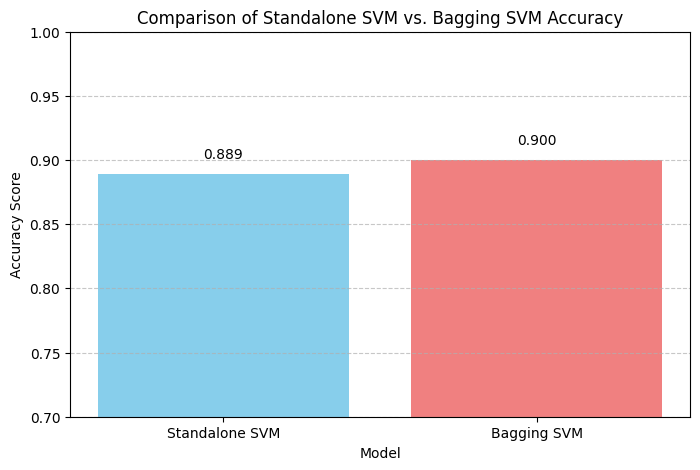

In [67]:
models = ['Standalone SVM', 'Bagging SVM']
accuracies = [svm_accuracy, bag_svm_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
plt.ylim(0.7, 1.0)
plt.title('Comparison of Standalone SVM vs. Bagging SVM Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Tree (Standalone and Bagging)

In [68]:
X_train, X_test, y_train, y_test= train_test_split(X, target, test_size=0.2, random_state=42)

In [75]:
from sklearn.tree import DecisionTreeClassifier
tree= DecisionTreeClassifier()
tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [76]:
dir(tree)
print('done')

done


In [77]:
tree.score(X_test, y_test)

0.8

In [86]:
bag_tree= BaggingClassifier(estimator=tree, n_estimators=100, max_samples=0.9, random_state=)
bag_tree.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.9,
                  n_estimators=100, random_state=42)

In [87]:
bag_tree.score(X_test, y_test)

0.8777777777777778

In [88]:
yp_tree= tree.predict(X_test)
yp_bag_tree= bag_tree.predict(X_test)

In [91]:
tree_accuracy = accuracy_score(y_test, yp_tree)
bag_tree_accuracy = accuracy_score(y_test, yp_bag_tree)

print(f"Standalone Tree Accuracy: {tree_accuracy:.4f}")
print(f"Bagging Tree Accuracy: {bag_tree_accuracy:.4f}")

Standalone Tree Accuracy: 0.8000
Bagging Tree Accuracy: 0.8778


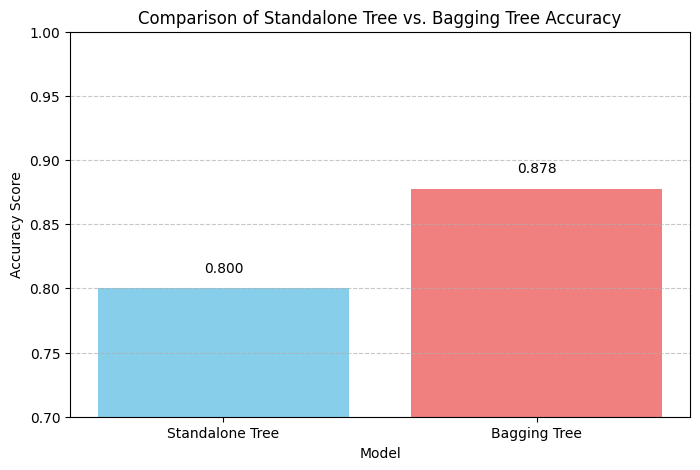

In [93]:
models = ['Standalone Tree', 'Bagging Tree']
accuracies = [tree_accuracy, bag_tree_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
plt.ylim(0.7, 1.0)
plt.title('Comparison of Standalone Tree vs. Bagging Tree Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

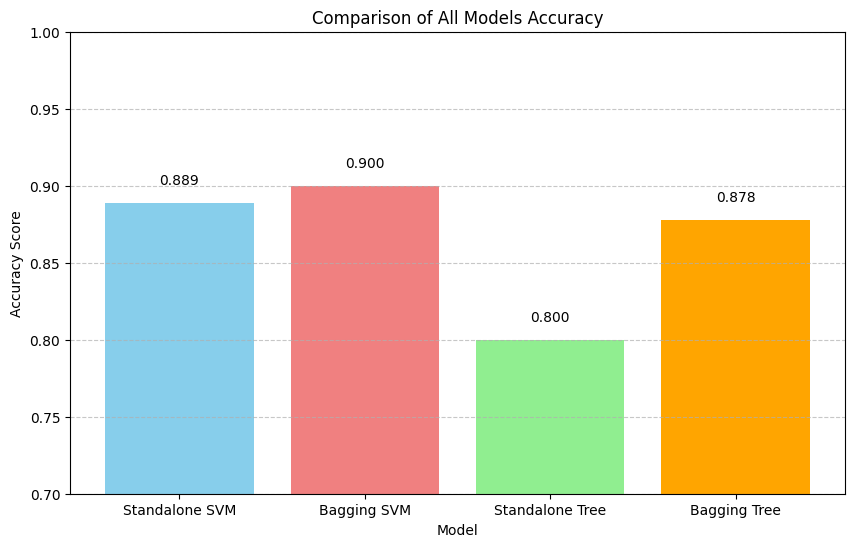

In [94]:
all_models = ['Standalone SVM', 'Bagging SVM', 'Standalone Tree', 'Bagging Tree']
all_accuracies = [svm_accuracy, bag_svm_accuracy, tree_accuracy, bag_tree_accuracy]

plt.figure(figsize=(10, 6))
plt.bar(all_models, all_accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'orange'])
plt.ylim(0.7, 1.0) # Set a reasonable y-limit for accuracy scores
plt.title('Comparison of All Models Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')

for i, accuracy in enumerate(all_accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()